## phase 6

In [3]:
# %%
import logging
import os

import pandas as pd
import numpy as np

from scipy.stats import loguniform, randint
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

import joblib
from joblib import parallel_backend

# تنظیم لاگ
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True,
)

# مسیر فایل فیچرها
FEATURE_CSV_PATH = "feature100.csv"

# مسیر ذخیره مدل‌ها
SVM_MODEL_PATH = "svm_phase6_tuned.pkl"
DT_MODEL_PATH = "dt_phase6.pkl"

# تنظیمات PCA
PCA_N_COMPONENTS = 100  # تعداد ثابت components برای کاهش حافظه

# استفاده از همه هسته‌های CPU برای سرعت بیشتر
N_JOBS = -1  # -1 = استفاده از همه هسته‌ها
N_CPU = os.cpu_count() or 1
print(f"Available CPU cores: {N_CPU}")
print(f"Using all CPU cores for parallel processing (n_jobs=-1)")

Available CPU cores: 20
Using all CPU cores for parallel processing (n_jobs=-1)


In [4]:
# %%
# خواندن داده‌ها از فایل CSV
df = pd.read_csv(FEATURE_CSV_PATH)

print("شکل کلی داده‌ها:", df.shape)
print(df.head())

# ستون‌های غیر فیچر را حذف می‌کنیم، بقیه ستون‌ها فیچر هستند
meta_cols = ["filename", "path", "class", "label", "split"]
feature_cols = [c for c in df.columns if c not in meta_cols]

print("تعداد فیچرها:", len(feature_cols))

# جدا کردن train و test بر اساس ستون split
train_df = df[df["split"] == "train"].copy()
test_df  = df[df["split"] == "test"].copy()

print("تعداد نمونه‌های train:", train_df.shape[0])
print("تعداد نمونه‌های test:", test_df.shape[0])

# ساخت X و y
X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df["label"].values

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df["label"].values

print("شکل X_train:", X_train.shape)
print("شکل X_test:", X_test.shape)

# نمایش تعداد فیچرها قبل از PCA
print(f"تعداد فیچرهای اصلی: {len(feature_cols)}")

شکل کلی داده‌ها: (23679, 1869)
                filename      class  label  split  aspect_ratio    mean_red  \
0  butterfly (1019).jpeg  butterfly      0  train      0.940000  163.673889   
1   butterfly (102).jpeg  butterfly      0  train      1.333333   31.376099   
2  butterfly (1020).jpeg  butterfly      0  train      1.500000   94.415405   
3  butterfly (1021).jpeg  butterfly      0  train      1.000000  214.120361   
4  butterfly (1023).jpeg  butterfly      0  train      1.639344  175.033691   

   mean_green   mean_blue     std_red  std_green  ...  hog_1754  hog_1755  \
0  172.006897  161.707520  104.156296  96.708549  ...  0.067204  0.081321   
1   31.791443   19.578003   44.298916  46.159184  ...  0.058301  0.299223   
2  118.286133   89.575745   69.398842  82.747208  ...  0.026036  0.088462   
3  182.354065  182.580139   69.926460  95.497864  ...  0.000000  0.193144   
4  181.705627  167.650269  103.348579  97.531174  ...  0.000000  0.335997   

   hog_1756  hog_1757  hog_1758

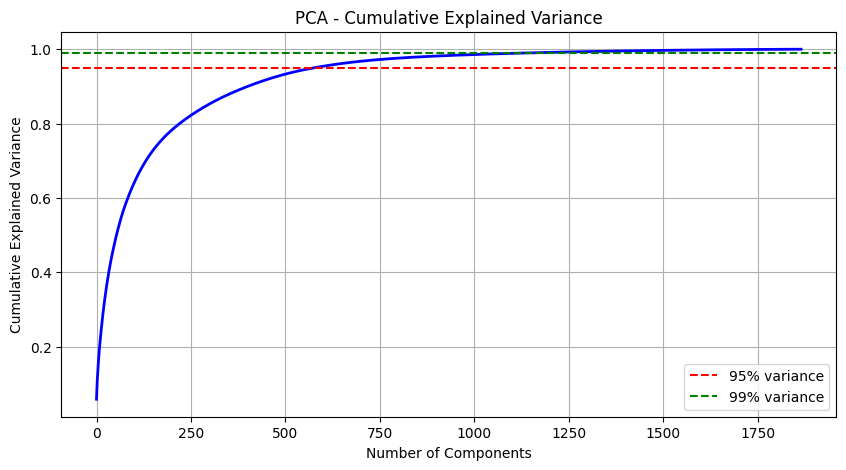

تعداد components برای 95% واریانس: 577
تعداد components برای 99% واریانس: 1141
کاهش ابعاد: 1865 -> 577 (با 95% واریانس)


In [5]:
# %%
# بررسی PCA و تعداد components مورد نیاز
import matplotlib.pyplot as plt

# نرمال‌سازی اولیه برای بررسی PCA
scaler_temp = StandardScaler()
X_train_scaled = scaler_temp.fit_transform(X_train)

# PCA با همه components
pca_full = PCA()
pca_full.fit(X_train_scaled)

# نمایش واریانس تجمعی
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, 'b-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.99, color='g', linestyle='--', label='99% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# تعداد components برای 95% و 99% واریانس
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"تعداد components برای 95% واریانس: {n_components_95}")
print(f"تعداد components برای 99% واریانس: {n_components_99}")
print(f"کاهش ابعاد: {len(feature_cols)} -> {n_components_95} (با 95% واریانس)")

# آزادسازی حافظه
del X_train_scaled, pca_full

In [6]:
# %%
# اعمال PCA قبل از تیونینگ برای کاهش حافظه
print("Applying PCA before hyperparameter tuning to reduce memory usage...")

# نرمال‌سازی و PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# انتخاب تعداد components بر اساس 95% واریانس
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"شکل X_train بعد از PCA: {X_train_pca.shape}")
print(f"شکل X_test بعد از PCA: {X_test_pca.shape}")
print(f"کاهش ابعاد: {X_train.shape[1]} -> {X_train_pca.shape[1]}")
print(f"واریانس حفظ شده: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# آزادسازی حافظه
del X_train_scaled, X_test_scaled
import gc
gc.collect()

Applying PCA before hyperparameter tuning to reduce memory usage...
شکل X_train بعد از PCA: (18443, 577)
شکل X_test بعد از PCA: (5236, 577)
کاهش ابعاد: 1865 -> 577
واریانس حفظ شده: 95.01%


3671

In [7]:
# %%
# تست SVM با پارامترهای دستی قبل از تیونینگ
print("=" * 50)
print("Testing SVM with manual parameters...")
print("=" * 50)

# تعریف SVM با پارامترهای دستی
clf = SVC(kernel='rbf', C=5, gamma='scale', random_state=42, probability=True)

# آموزش روی داده‌های PCA شده
clf.fit(X_train_pca, y_train)

# دقت روی TRAIN
y_train_pred_manual = clf.predict(X_train_pca)
train_acc_manual = accuracy_score(y_train, y_train_pred_manual)
print(f"SVM (manual params) train accuracy: {train_acc_manual:.4f}")

# دقت روی TEST
y_test_pred_manual = clf.predict(X_test_pca)
test_acc_manual = accuracy_score(y_test, y_test_pred_manual)
print(f"SVM (manual params) test accuracy: {test_acc_manual:.4f}")

print("\nClassification report (SVM manual params):")
print(classification_report(y_test, y_test_pred_manual))

print("Confusion matrix (SVM manual params):")
print(confusion_matrix(y_test, y_test_pred_manual))

print("\nManual SVM parameters used:")
print(f"  kernel='rbf', C=7, gamma='scale'")

# ذخیره مدل دستی
from joblib import dump
dump(clf, "svm_phase6_dasti.pkl")
print("\n✓ Model saved as svm_phase6_dasti.pkl")

Testing SVM with manual parameters...
SVM (manual params) train accuracy: 0.9982
SVM (manual params) test accuracy: 0.6010

Classification report (SVM manual params):
              precision    recall  f1-score   support

           0       0.69      0.65      0.67       422
           1       0.53      0.30      0.38       334
           2       0.60      0.67      0.63       620
           3       0.58      0.46      0.51       373
           4       0.54      0.64      0.59       973
           5       0.61      0.39      0.48       289
           6       0.65      0.63      0.64       525
           7       0.46      0.46      0.46       364
           8       0.70      0.80      0.74       964
           9       0.55      0.49      0.52       372

    accuracy                           0.60      5236
   macro avg       0.59      0.55      0.56      5236
weighted avg       0.60      0.60      0.59      5236

Confusion matrix (SVM manual params):
[[273   5  13   1  33   1   3   3  7

In [ ]:
# %%
# استراتژی Cross-Validation: K=5 با حفظ توزیع کلاس‌ها
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

# توزیع هایپرپارامترها برای RandomizedSearchCV (بدون PCA چون قبلاً اعمال شد)
svm_param_distributions = {
    "C": loguniform(1e-2, 1e3),
    "gamma": loguniform(1e-4, 1),
    "kernel": ["rbf", "poly"],
}

svm_n_iter = 25
print(f"Starting SVM RandomizedSearchCV with {svm_n_iter} iterations...")
print(f"Total fits: {svm_n_iter} configs × 5 folds = {svm_n_iter * 5} fits")

# تنظیم RandomizedSearchCV - بدون parallel_backend wrapper
svm_search = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=svm_param_distributions,
    n_iter=svm_n_iter,
    cv=cv_strategy,
    scoring="accuracy",
    random_state=42,
    n_jobs=N_JOBS,  # استفاده از همه هسته‌ها
    verbose=3,  # افزایش verbose برای لاگ بیشتر
)

# اجرای fit بدون parallel_backend wrapper (لاگ‌ها نمایش داده می‌شوند)
print("=" * 50)
print("Starting SVM tuning...")
print("=" * 50)
svm_search.fit(X_train_pca, y_train)
print("SVM RandomizedSearchCV complete!")

# بهترین هایپرپارامترها
print(f"\nBest SVM parameters: {svm_search.best_params_}")
print(f"Best cross-validated accuracy: {svm_search.best_score_:.4f}")

# لاگ کردن همه کانفیگ‌ها
cv_results_ = svm_search.cv_results_
print("\nAll configurations:")
for i in range(len(cv_results_["params"])):
    params = cv_results_["params"][i]
    mean_score = cv_results_["mean_test_score"][i]
    std_score = cv_results_["std_test_score"][i]
    rank = cv_results_["rank_test_score"][i]
    print(f"Config {i+1:03d} | params={params} | acc={mean_score:.4f} ± {std_score:.4f} | rank={rank}")

best_svm = svm_search.best_estimator_

# دقت روی TRAIN
y_train_pred = best_svm.predict(X_train_pca)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"\nSVM (tuned with PCA) train accuracy: {train_acc:.4f}")

# دقت و گزارش روی TEST
y_test_pred = best_svm.predict(X_test_pca)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"SVM (tuned with PCA) test accuracy: {test_acc:.4f}")

print("\nClassification report (SVM tuned with PCA):")
print(classification_report(y_test, y_test_pred))

print("Confusion matrix (SVM tuned with PCA):")
print(confusion_matrix(y_test, y_test_pred))

# ذخیره مدل کامل (scaler + pca + svm)
full_svm_pipeline = Pipeline([
    ("scaler", scaler),
    ("pca", pca),
    ("svm", best_svm),
])
joblib.dump(full_svm_pipeline, SVM_MODEL_PATH)
print(f"\nTuned SVM model saved to: {SVM_MODEL_PATH}")

Starting SVM RandomizedSearchCV with 25 iterations...
Total fits: 25 configs × 5 folds = 125 fits
Starting SVM tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
SVM RandomizedSearchCV complete!

Best SVM parameters: {'C': np.float64(84.31013932082456), 'gamma': np.float64(0.0006290644294586153), 'kernel': 'rbf'}
Best cross-validated accuracy: 0.5622

All configurations:
Config 001 | params={'C': np.float64(0.7459343285726545), 'gamma': np.float64(0.6351221010640696), 'kernel': 'rbf'} | acc=0.1997 ± 0.0002 | rank=20
Config 002 | params={'C': np.float64(79.15074397656205), 'gamma': np.float64(0.024400607090817518), 'kernel': 'poly'} | acc=0.4983 ± 0.0079 | rank=4
Config 003 | params={'C': np.float64(0.060252157362038566), 'gamma': np.float64(0.0001707396743152812), 'kernel': 'poly'} | acc=0.1997 ± 0.0002 | rank=20
Config 004 | params={'C': np.float64(0.46616864139127684), 'gamma': np.float64(0.0003727925903376988), 'kernel': 'rbf'} | acc=0.4912 ± 0.0074 | rank=11
Co

In [ ]:
# %%
# هایپرپارامترها برای Decision Tree
dt_param_distributions = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
}

dt_n_iter = 30
print(f"\nStarting Decision Tree RandomizedSearchCV with {dt_n_iter} iterations...")
print(f"Total fits: {dt_n_iter} configs × 5 folds = {dt_n_iter * 5} fits")

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_distributions,
    n_iter=dt_n_iter,
    cv=cv_strategy,
    scoring="accuracy",
    random_state=42,
    n_jobs=N_JOBS,
    verbose=3,  # افزایش verbose
)

print("=" * 50)
print("Starting Decision Tree tuning...")
print("=" * 50)
dt_search.fit(X_train_pca, y_train)
print("Decision Tree RandomizedSearchCV complete!")

print(f"\nBest DT parameters: {dt_search.best_params_}")
print(f"Best cross-validated accuracy: {dt_search.best_score_:.4f}")

best_dt = dt_search.best_estimator_

# دقت روی TRAIN
y_train_pred_dt = best_dt.predict(X_train_pca)
train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
print(f"\nDecision Tree (tuned with PCA) train accuracy: {train_acc_dt:.4f}")

# دقت روی TEST
y_pred_dt = best_dt.predict(X_test_pca)
dt_acc = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree (tuned with PCA) test accuracy: {dt_acc:.4f}")

print("\nClassification report (Decision Tree with PCA):")
print(classification_report(y_test, y_pred_dt))

print("Confusion matrix (Decision Tree with PCA):")
print(confusion_matrix(y_test, y_pred_dt))

# ذخیره مدل کامل
full_dt_pipeline = Pipeline([
    ("scaler", scaler),
    ("pca", pca),
    ("dt", best_dt),
])
joblib.dump(full_dt_pipeline, DT_MODEL_PATH)
print(f"\nDecision Tree model saved to: {DT_MODEL_PATH}")


Starting Decision Tree RandomizedSearchCV with 30 iterations...
Total fits: 30 configs × 5 folds = 150 fits
Starting Decision Tree tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Decision Tree RandomizedSearchCV complete!

Best DT parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 15}
Best cross-validated accuracy: 0.2729

Decision Tree (tuned with PCA) train accuracy: 0.4656
Decision Tree (tuned with PCA) test accuracy: 0.2869

Classification report (Decision Tree with PCA):
              precision    recall  f1-score   support

           0       0.26      0.23      0.24       422
           1       0.12      0.06      0.08       334
           2       0.26      0.36      0.30       620
           3       0.23      0.12      0.16       373
           4       0.26      0.28      0.27       973
           5       0.14      0.03      0.06       289
           6       0.31      0.23      0.26       525
           7     

In [ ]:
# %%
# مقایسه نهایی مدل‌ها
print("=" * 50)
print("مقایسه نهایی مدل‌ها")
print("=" * 50)
print(f"SVM (with PCA) - Test Accuracy: {test_acc:.4f}")
print(f"Decision Tree (with PCA) - Test Accuracy: {dt_acc:.4f}")
print(f"\nتعداد فیچرهای اصلی: {len(feature_cols)}")
print(f"تعداد components بعد از PCA: {pca.n_components_}")
print(f"واریانس حفظ شده: {sum(pca.explained_variance_ratio_)*100:.2f}%")

مقایسه نهایی مدل‌ها
SVM (with PCA) - Test Accuracy: 0.6012
Decision Tree (with PCA) - Test Accuracy: 0.2869

تعداد فیچرهای اصلی: 1865
تعداد components بعد از PCA: 577
واریانس حفظ شده: 95.01%
